# World Cup 2026: an honest expected-goals chart, and the one profile that survives it

A debate I kept circling back to while rebuilding this chart was really a question of what a graph claims to show versus what it measures underneath, which I found compelling just like presidential approval graphs from the past compared to now can be misleading were (such as the LBJ and Biden approval graphs), where the surface reading and the real story pull apart once you look closer.

The chart I started with came from footballytics, plotting World Cup 2026 attackers along a blended vertical axis of 0.3 times goals plus 0.7 times xG per 90, and I thought the underlying concept worked well enough, since two axes sort scorers from creators and per-90 rates let you compare players across uneven minutes, though the execution had three problems I found serious enough to rebuild the whole thing around.

**The first problem was the vertical axis**, which the chart labeled as finishing quality even though the formula underneath measured shot volume and chance quality instead, and I thought this was the most misleading part, because a high-volume shooter posts a big number on that axis whether or not he finishes, so the metric buries the exact signal it claims to show. Genuine finishing shows up as goals minus xG, the overperformance a player generates beyond his chances, so I moved the vertical axis to goals per 90 minus xG per 90.

**The second problem was creation.** Once the finishing axis is fixed, I still needed the second dimension the original was reaching for, and I settled on xA per 90 because xA credits the quality of the chance a player builds, valuing a cutback into an open six-yard box far higher than a hopeful cross, whereas raw assists punish a creator whose teammates fail to finish, so xA isolates the creation a player controls from the conversion he does not.

**The third problem was sample size, which I thought was the worst of the three**, because a World Cup gives each player only a handful of games and per-90 rates off small minutes swing wildly, yet the original chart weighted a cameo substitute the same as a player who started every match, so someone like Deniz Undav topped early cuts of the data on rates drawn from under a hundred minutes. I set a floor of 270 minutes, around three full matches, and I sized every dot by minutes played, so a small sample shows up as a small dot you learn to read with more caution.

I also stripped out the quadrant labels the original leaned on, the ones sorting players into finishers, creators, and wasteful, because they bake a verdict into a five-game sample, and the clearest example of the damage is Olise and Wirtz, both of whom land low on finishing in a way that reads as a flaw until you notice they carry tiny personal shot volumes and generate their value on the creation axis instead.

The section at the end does not throw the finishing axis away, it calibrates it. I put a confidence band on goals minus xG so you know how firmly each position can be read, and that same idea is what makes the one genuinely exceptional profile in this tournament stand out for a reason the statistics actually support.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compiled from FotMob World Cup 2026 player stats.
# goals/90, xG/90, minutes from the finishing leaderboard (>=270 min).
# xA/90 from FotMob's per-90 creation stats, cross-checked against published season totals.
df = pd.read_csv("wc2026_attackers.csv")
df["finishing_p90"] = df["goals_p90"] - df["xg_p90"]   # overperformance = the true finishing signal
df.sort_values("finishing_p90", ascending=False).head()

,name,goals_p90,xg_p90,minutes,xa_p90,finishing_p90
0,Dembele,0.97,0.30,462,0.29,0.67
1,Haaland,1.75,1.08,465,0.06,0.67
2,Messi,1.76,1.10,530,0.57,0.66
3,Kane,1.22,0.70,563,0.16,0.52
4,Quinones,0.87,0.35,414,0.09,0.52


## Chart 1: finishing versus creation, minutes-weighted

Vertical axis is finishing (goals minus xG per 90). Horizontal is creation (xA per 90). Every dot is a player past the 270-minute floor, sized by minutes. There are no quadrant lines and no labels sorting players into good or bad. Where a player sits is a real fact about this tournament: he did score above or below his chances, and he did create at this rate. What the next section adds is how firmly each of those two readings can be pushed.

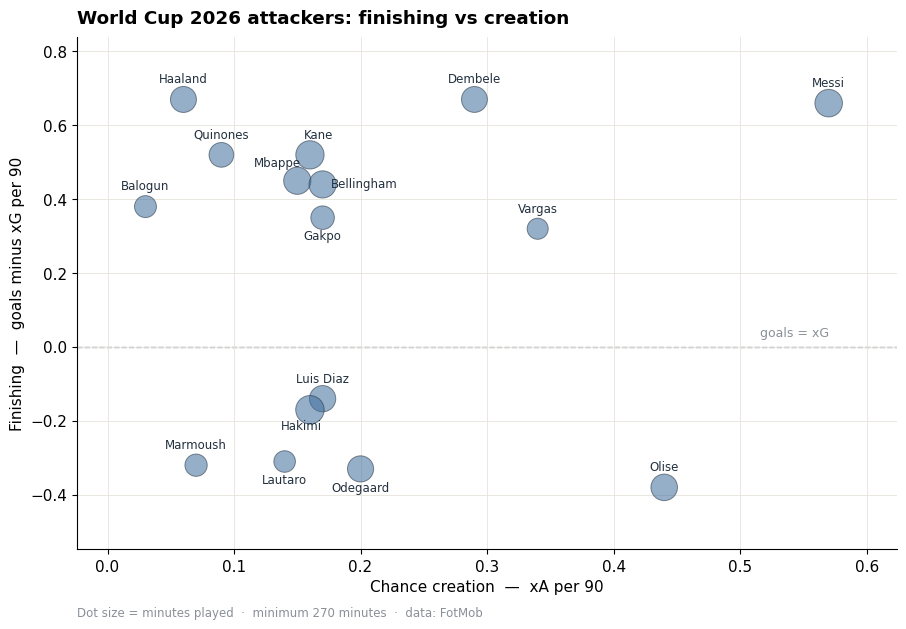

In [2]:
INK, ACCENT, MUTED, GRID = "#22303f", "#3f6d9c", "#8a8f98", "#e6e3db"
plt.rcParams.update({"font.size":11, "figure.facecolor":"white", "axes.facecolor":"white"})

off = {"Mbappe":(-14,10),"Bellingham":(30,-2),"Gakpo":(0,-16),"Kane":(6,12),"Hakimi":(-6,-14),
       "Lautaro":(0,-16),"Odegaard":(0,-16)}
fig, ax = plt.subplots(figsize=(9.2,6.4))
sizes = (df["minutes"]/df["minutes"].max()*380)+40
ax.scatter(df["xa_p90"], df["finishing_p90"], s=sizes, color=ACCENT, alpha=0.55,
           edgecolor=INK, linewidth=0.7, zorder=3)
ax.axhline(0, color=MUTED, lw=1, ls="--", zorder=1)
ax.text(df["xa_p90"].max(), 0.02, "goals = xG", color=MUTED, fontsize=9, ha="right", va="bottom")
for _, r in df.iterrows():
    dx, dy = off.get(r["name"], (0,12))
    ax.annotate(r["name"], (r["xa_p90"], r["finishing_p90"]), xytext=(dx,dy),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_xlabel("Chance creation  —  xA per 90")
ax.set_ylabel("Finishing  —  goals minus xG per 90")
ax.set_title("World Cup 2026 attackers: finishing vs creation", fontweight="bold", loc="left", pad=10)
ax.grid(color=GRID, lw=0.6, zorder=0); ax.margins(x=0.10, y=0.16)
ax.text(0.0,-0.13,"Dot size = minutes played  ·  minimum 270 minutes  ·  data: FotMob",
        transform=ax.transAxes, fontsize=8.5, color=MUTED)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

How to read it. Up and to the right means both scoring above expectation and creating: Messi sits alone out there, off 530 minutes, so that position is built on real volume rather than a cameo. Straight up with little rightward drift is a scorer who does not create, like Haaland. Far right and low is a creator whose own shots are secondary. A player below the line has scored fewer than his chances predicted over these games, which is a fact about the tournament, not a proven flaw in his finishing.

The two axes are not equally firm, though, and the reason is worth making explicit before reading too much into any vertical position.

## Calibrating the two axes: how firmly can each be read?

The two axes rest on different numbers of events, and that alone decides how much you can trust them.

**Finishing rests on rare events.** A player takes only a few shots a game, and each converts with a small probability, so over five games his goals-minus-xG figure sits on a handful of chances. One lucky finish or one miss swings it hard.

**Creation rests on frequent events.** A player creates chances far more often than he scores, so xA accumulates over many more events across the same minutes, and the random swings cancel out faster. In the same tournament, creation is the steadier of the two readings.

I can put a number on the finishing uncertainty. Goals is a sum of Bernoulli trials, one per shot, each converting with probability equal to its xG. Treating a player's total xG as the fixed expectation, the standard deviation of goals minus xG is about the square root of total xG, which converts to a per-90 band. The smaller a player's total xG, the wider that band.

In [3]:
df["total_xg"] = df["xg_p90"] * df["minutes"]/90.0          # expected goals over the tournament
df["sd_finishing_p90"] = np.sqrt(df["total_xg"]) / (df["minutes"]/90.0)
df["ci95_p90"] = 1.96 * df["sd_finishing_p90"]

crosses = ((df["finishing_p90"] - df["ci95_p90"] < 0) &
           (df["finishing_p90"] + df["ci95_p90"] > 0)).sum()
print(f"{crosses} of {len(df)} players have a 95% finishing band that crosses zero.")
df.sort_values("finishing_p90", ascending=False)[
    ["name","finishing_p90","minutes","total_xg","ci95_p90"]
].round(2)

15 of 16 players have a 95% finishing band that crosses zero.


,name,finishing_p90,minutes,total_xg,ci95_p90
0,Dembele,0.67,462,1.54,0.47
1,Haaland,0.67,465,5.58,0.90
2,Messi,0.66,530,6.48,0.85
3,Kane,0.52,563,4.38,0.66
4,Quinones,0.52,414,1.61,0.54
5,Mbappe,0.45,518,5.41,0.79
6,Bellingham,0.44,515,2.58,0.55
7,Balogun,0.38,314,1.67,0.73
8,Gakpo,0.35,371,1.57,0.60
9,Vargas,0.32,285,1.01,0.62


Fifteen of sixteen finishing figures have a 95% band that crosses zero. That does not make the finishing axis meaningless, it tells you how to read it: as what happened in five games, not as settled finishing skill you can project forward. The creation axis needs no such heavy discount, because it rests on the higher event count. The chart below shows the finishing bands directly.

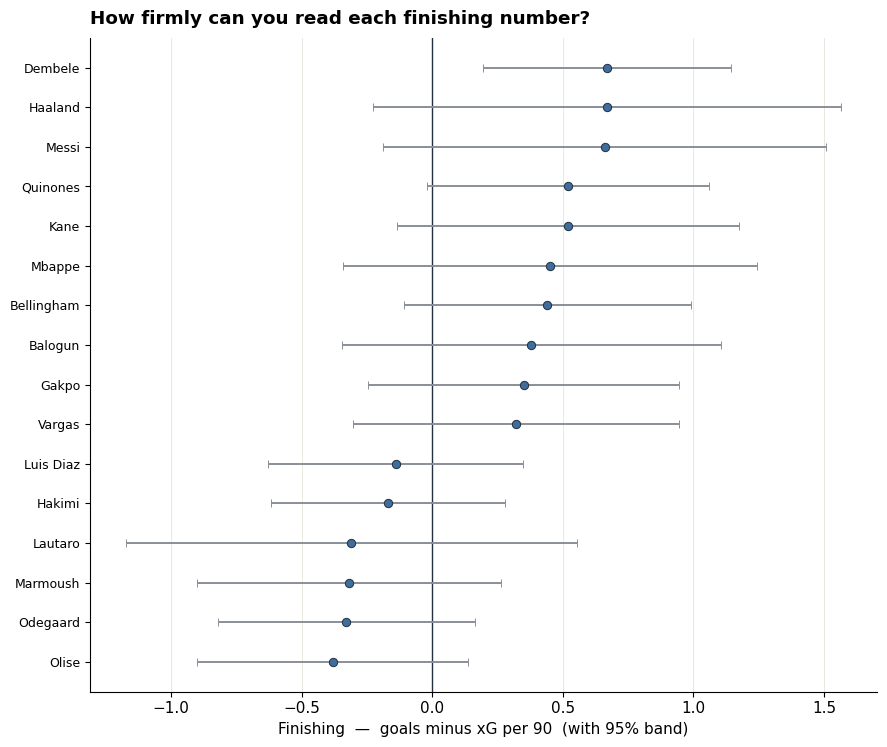

In [4]:
d2 = df.sort_values("finishing_p90")
fig, ax = plt.subplots(figsize=(9,7.6))
y = np.arange(len(d2))
ax.errorbar(d2["finishing_p90"], y, xerr=d2["ci95_p90"], fmt="o", color=ACCENT,
            ecolor=MUTED, elinewidth=1.4, capsize=3, markersize=6,
            markeredgecolor=INK, markeredgewidth=0.7, zorder=3)
ax.axvline(0, color=INK, lw=1, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(d2["name"], fontsize=9)
ax.set_xlabel("Finishing  —  goals minus xG per 90  (with 95% band)")
ax.grid(axis="x", color=GRID, lw=0.6, zorder=0)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.set_title("How firmly can you read each finishing number?", fontweight="bold", loc="left", pad=10)
plt.tight_layout(); plt.show()

A minutes floor removes the cameo-substitute bias, but it cannot widen the sample a short tournament allows. The last chart shows the finishing band shrinking as minutes grow, with the World Cup range shaded. Even at the top of that range, the band stays roughly twice as wide as it becomes over a full club season. This is a statement about the finishing axis specifically, the one built on rare events.

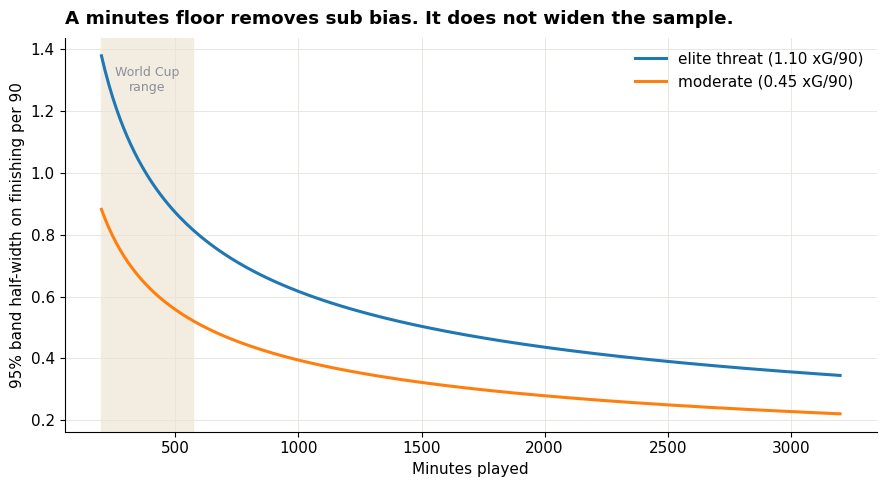

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
mins = np.linspace(200, 3200, 200)
for xg, label in [(1.10,"elite threat (1.10 xG/90)"), (0.45,"moderate (0.45 xG/90)")]:
    total = xg*mins/90.0
    ci = 1.96*np.sqrt(total)/(mins/90.0)
    ax.plot(mins, ci, lw=2.2, label=label)
ax.axvspan(200, 570, color="#f3ede1", zorder=0)
ax.text(385, ax.get_ylim()[1]*0.88, "World Cup\nrange", ha="center", fontsize=9, color=MUTED)
ax.set_xlabel("Minutes played")
ax.set_ylabel("95% band half-width on finishing per 90")
ax.set_title("A minutes floor removes sub bias. It does not widen the sample.", fontweight="bold", loc="left", pad=10)
ax.legend(frameon=False); ax.grid(color=GRID, lw=0.6, zorder=0)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## What I take from this, and the one profile that survives every filter

The rebuilt chart fixes the original's three flaws: a finishing axis that measures finishing, a creation axis that isolates creation, and a minutes floor with sized dots that stops cameo samples from distorting the picture. The statistics do not throw the finishing axis away, they calibrate it, telling you to read a short-tournament finishing number as what happened rather than as proven skill, while the creation axis, built on far more events, carries more weight on its own.

One conclusion survives every filter I applied, and it is the one I did not expect to hold up. The whole point of this project was to show how little you should trust a five-game sample, and the confidence bands make that case bluntly, since fifteen of the sixteen finishing numbers cannot be separated from average once you account for how few shots they rest on. Messi is the exception, and the reason is worth sitting with. His standout number is not finishing, where the uncertainty is widest, it is creation, and chance creation accumulates over far more events than goals do, so xA steadies at a sample size where finishing is still guesswork. His xA per 90 does not sit slightly ahead of the field, it sits alone, off 530 minutes rather than a cameo, which means the one signal the statistics say you can actually lean on is the one where he laps everyone.

What makes that stand out is where it happens on the chart. Messi is not parked in the pure-creator corner trading goals for assists. He sits in the complete-attacker region, scoring above his expected goals while creating more than any other player in the tournament, and he does it at 39. Read against everything else in this analysis, that is the rare case where the caveats fall away. Take out the small-sample finishing noise, take out the cameo-minute distortions, hold only the metric that survives scrutiny, and one player is still out on his own. A footballer producing elite scoring threat and league-leading creation in the same tournament, near the end of a career that long, is a combination the historical record does not really offer a second example of. No five games could prove that on their own, but the data is fully consistent with it, and that is the most a careful reading will ever let you claim.

**Data note.** Figures were compiled from FotMob's World Cup 2026 player stats during analysis (`wc2026_attackers.csv`). Per-90 xA was taken from FotMob's per-90 creation stats and cross-checked against published season totals, which agreed to within about 0.02 for most players. The finishing model treats each player's total xG as a fixed expectation and goals as the random outcome, a standard first-order approximation rather than a full hierarchical model.